In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
archivo_caidas = Path("C:\\Users\\PC\\Documents\\GitHub\\Proyecto-microprocesadores1\\Documentos\\Datos\\datos_capturados_caidas.csv")
archivo_normales = Path("C:\\Users\\PC\\Documents\\GitHub\\Proyecto-microprocesadores1\\Documentos\\Datos\\datos_capturados_normales.csv")

ARCHIVOS = {
    archivo_caidas: 1,      # caída
    archivo_normales: 0     # normal
}


In [6]:
COLUMNAS = [
    'cadera_ax','cadera_ay','cadera_az',
    'cadera_gx','cadera_gy','cadera_gz',
    'pierna_ax','pierna_ay','pierna_az',
    'pierna_gx','pierna_gy','pierna_gz'
]
df_caidas = pd.read_csv(archivo_caidas)
df_normales = pd.read_csv(archivo_normales)

print(df_caidas.columns)
print(df_normales.columns)

Index(['cadera_ax', 'cadera_ay', 'cadera_az', 'cadera_gx', 'cadera_gy',
       'cadera_gz', 'pierna_ax', 'pierna_ay', 'pierna_az', 'pierna_gx',
       'pierna_gy', 'pierna_gz'],
      dtype='object')
Index(['cadera_ax', 'cadera_ay', 'cadera_az', 'cadera_gx', 'cadera_gy',
       'cadera_gz', 'pierna_ax', 'pierna_ay', 'pierna_az', 'pierna_gx',
       'pierna_gy', 'pierna_gz'],
      dtype='object')


In [7]:
WINDOW_SIZE = 40
OVERLAP = 20

datos_totales = []
etiquetas_totales = []

for archivo, etiqueta in ARCHIVOS.items():
    print("Procesando:", archivo.name)

    df = pd.read_csv(archivo)

    df = df[COLUMNAS].dropna()

    for i in range(0, len(df) - WINDOW_SIZE + 1, OVERLAP):
        ventana = df.iloc[i:i+WINDOW_SIZE].values
        datos_totales.append(ventana)
        etiquetas_totales.append(etiqueta)

X = np.array(datos_totales)
y = np.array(etiquetas_totales)

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Procesando: datos_capturados_caidas.csv
Procesando: datos_capturados_normales.csv
Forma de X: (9074, 40, 12)
Forma de y: (9074,)


In [8]:
num_muestras, pasos, num_features = X.shape

X_2d = X.reshape(-1, num_features)

scaler = StandardScaler()
X_2d = scaler.fit_transform(X_2d)

X = X_2d.reshape(num_muestras, pasos, num_features)

print(X.shape)

(9074, 40, 12)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(7259, 40, 12)
(1815, 40, 12)


In [10]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW_SIZE, num_features)),
    Dropout(0.3),

    LSTM(32),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 40, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,217 (129.75 KB)

 Trainable params: 33,217 (129.75 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9953 - loss: 0.0172 - val_accuracy: 0.9956 - val_loss: 0.0140
Epoch 2/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9964 - loss: 0.0115 - val_accuracy: 0.9928 - val_loss: 0.0233
Epoch 3/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9966 - loss: 0.0110 - val_accuracy: 0.9923 - val_loss: 0.0152
Epoch 4/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9941 - loss: 0.0155 - val_accuracy: 0.9928 - val_loss: 0.0239
Epoch 5/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9950 - loss: 0.0150 - val_accuracy: 0.9906 - val_loss: 0.0353
Epoch 6/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9945 - loss: 0.0212 - val_accuracy: 0.9923 - val_loss: 0.0310
Epoch 7/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9957 - loss: 0.0115 - val_accuracy: 0.9928 - val_loss: 0.0252
Epoch 8/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9983 - loss: 0.0060 - val_accu

In [14]:
loss, acc = model.evaluate(X_test, y_test)

print("Pérdida:", loss)
print("Precisión:", acc)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9956 - loss: 0.0140
Pérdida: 0.014017890207469463
Precisión: 0.9955922961235046


In [15]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

print(classification_report(
    y_test,
    y_pred,
    target_names=['Normal', 'Caída']
))

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00       944
       Caída       1.00      0.99      1.00       871

    accuracy                           1.00      1815
   macro avg       1.00      1.00      1.00      1815
weighted avg       1.00      1.00      1.00      1815



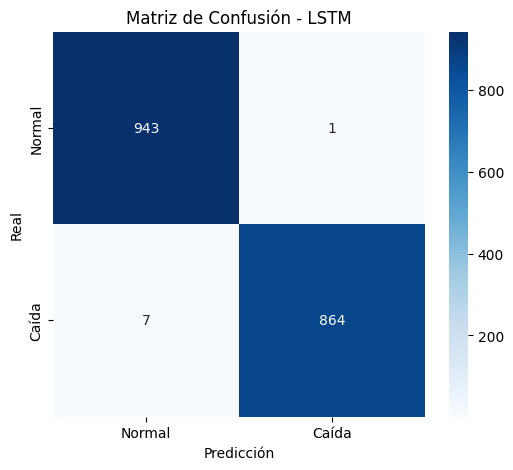

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Caída'],
    yticklabels=['Normal', 'Caída']
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - LSTM")
plt.show()

In [17]:
model.save("modelo_lstm_caidas.h5")
print("Modelo guardado correctamente")

Modelo guardado correctamente
